In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

n_students = 100

students = pd.DataFrame({
    'student_id': [f"S{i+1:03d}" for i in range(n_students)],

    # Attendance / Presence
    'absence_regular': np.random.randint(0, 10, n_students),
    'absence_before_holiday': np.random.randint(0, 3, n_students),
    'absence_after_holiday': np.random.randint(0, 3, n_students),
    'absence_sick': np.random.randint(0, 4, n_students),
    'present_count': np.random.randint(70, 100, n_students),
    'late_count': np.random.randint(0, 10, n_students),

    # Homework / Classwork
    'hw_submission': np.random.uniform(0.6, 1.0, n_students),
    'hw_quality': np.random.uniform(0.5, 1.0, n_students),
    'cw_submission': np.random.uniform(0.6, 1.0, n_students),
    'cw_quality': np.random.uniform(0.5, 1.0, n_students),

    # Exam
    'marks_math': np.random.randint(50, 100, n_students),
    'marks_english': np.random.randint(40, 95, n_students),
    'marks_science': np.random.randint(45, 100, n_students),

    'answer_sensibility': np.random.uniform(0.5, 1.0, n_students),
    'completion_rate': np.random.uniform(0.6, 1.0, n_students),
    'unrelated_answer': np.random.uniform(0.0, 0.2, n_students),

    # Skills
    'communication': np.random.uniform(0.5, 1.0, n_students),
    'critical_thinking': np.random.uniform(0.5, 1.0, n_students),
    'discipline': np.random.uniform(0.5, 1.0, n_students),
    'study_mgmt': np.random.uniform(0.5, 1.0, n_students)
})

In [3]:
students['total_absence'] = (
    students['absence_regular']
    + students['absence_before_holiday']
    + students['absence_after_holiday']
    + students['absence_sick']
)

students['presence_ratio'] = students['present_count'] / (students['present_count'] + students['total_absence'])
students['late_ratio'] = students['late_count'] / (students['present_count'] + students['late_count'])
students['present_to_late_ratio'] = students['present_count'] / (students['late_count'] + 1)

In [4]:
def normalize(val, vmin, vmax):
    """Normalize to 1–100 range"""
    return np.clip(1 + 99 * (val - vmin) / (vmax - vmin + 1e-6), 1, 100)

def calc_ratings(row):
    # Attendance Sub-sectors
    r_att_regular = normalize(10 - row['absence_regular'], 0, 10)
    r_att_holiday = normalize(5 - (row['absence_before_holiday'] + row['absence_after_holiday']), 0, 5)
    r_att_sick = normalize(4 - row['absence_sick'], 0, 4)
    r_presence_ratio = normalize(row['presence_ratio'], 0.7, 1.0)
    r_late = normalize(1 - row['late_ratio'], 0, 1)
    
    attendance_rating = np.mean([r_att_regular, r_att_holiday, r_att_sick, r_presence_ratio, r_late])

    # Homework/Classwork Sub-sectors
    r_hw_sub = normalize(row['hw_submission'], 0.5, 1.0)
    r_hw_qual = normalize(row['hw_quality'], 0.5, 1.0)
    r_cw_sub = normalize(row['cw_submission'], 0.5, 1.0)
    r_cw_qual = normalize(row['cw_quality'], 0.5, 1.0)
    hw_cw_rating = np.mean([r_hw_sub, r_hw_qual, r_cw_sub, r_cw_qual])

    # Exam Sub-sectors
    avg_marks = np.mean([row['marks_math'], row['marks_english'], row['marks_science']])
    r_marks = normalize(avg_marks, 40, 100)
    r_sensibility = normalize(row['answer_sensibility'], 0.5, 1.0)
    r_completion = normalize(row['completion_rate'], 0.6, 1.0)
    r_unrelated = normalize(1 - row['unrelated_answer'], 0, 1)
    exam_rating = np.mean([r_marks, r_sensibility, r_completion, r_unrelated])

    # Skill Sub-sectors
    r_comm = normalize(row['communication'], 0.5, 1.0)
    r_ct = normalize(row['critical_thinking'], 0.5, 1.0)
    r_discipline = normalize(row['discipline'], 0.5, 1.0)
    r_study = normalize(row['study_mgmt'], 0.5, 1.0)
    skill_rating = np.mean([r_comm, r_ct, r_discipline, r_study])

    # Final FIFA-like Rating
    final_rating = (
        0.3 * attendance_rating +
        0.3 * hw_cw_rating +
        0.3 * exam_rating +
        0.1 * skill_rating
    )

    # Return detailed breakdown
    return pd.Series({
        'attendance_rating': attendance_rating,
        'homework_classwork_rating': hw_cw_rating,
        'exam_rating': exam_rating,
        'skill_rating': skill_rating,
        'fifa_rating': final_rating
    })

In [5]:
students = pd.concat([students, students.apply(calc_ratings, axis=1)], axis=1)
students.head()

,student_id,absence_regular,absence_before_holiday,absence_after_holiday,absence_sick,present_count,late_count,hw_submission,hw_quality,cw_submission,...,study_mgmt,total_absence,presence_ratio,late_ratio,present_to_late_ratio,attendance_rating,homework_classwork_rating,exam_rating,skill_rating,fifa_rating
0,S001,6,1,1,1,76,9,0.755681,0.955464,0.682533,...,0.721358,9,0.894118,0.105882,7.600000,66.165227,53.215202,65.548386,33.231984,56.186862
1,S002,3,0,1,1,94,2,0.604335,0.911269,0.745708,...,0.722895,5,0.949495,0.020833,31.333333,81.404084,58.729203,47.801664,51.881754,61.430293
2,S003,7,2,2,1,73,4,0.962153,0.974900,0.801367,...,0.862258,12,0.858824,0.051948,14.600000,55.003723,68.603994,46.034881,48.358479,54.832531
3,S004,4,2,0,1,82,5,0.636515,0.862860,0.876158,...,0.507911,7,0.921348,0.057471,13.666667,72.880983,61.205924,55.274082,44.740893,59.932475
4,S005,6,1,0,1,89,8,0.727725,0.806708,0.615725,...,0.670545,8,0.917526,0.082474,9.888889,72.133638,51.998354,71.762872,55.573647,63.695127


In [6]:
# ---------------------------------------------------------
# 4️⃣  Quick Correlation Insight
# ---------------------------------------------------------
corr = students.corr(numeric_only=True)['fifa_rating'].sort_values(ascending=False)
display(corr.head(10))

fifa_rating                  1.000000
homework_classwork_rating    0.601187
attendance_rating            0.550786
presence_ratio               0.533107
cw_quality                   0.482361
exam_rating                  0.440041
cw_submission                0.437828
skill_rating                 0.401079
completion_rate              0.296405
critical_thinking            0.288503
Name: fifa_rating, dtype: float64

In [7]:
# ---------------------------------------------------------
# 5️⃣  Simple Machine Learning Model (from scratch)
# ---------------------------------------------------------

# Choose features
features = [
    'presence_ratio', 'hw_submission', 'hw_quality',
    'cw_submission', 'cw_quality',
    'marks_math', 'marks_english', 'marks_science',
    'communication', 'critical_thinking',
    'discipline', 'study_mgmt'
]

X = students[features].to_numpy()
y = students['fifa_rating'].to_numpy().reshape(-1, 1)

# Normalize features
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_norm = (X - X_mean) / (X_std + 1e-6)

# Add bias term
X_b = np.c_[np.ones((X_norm.shape[0], 1)), X_norm]

# Initialize weights
theta = np.random.randn(X_b.shape[1], 1)

# Gradient Descent Parameters
lr = 0.01
n_iter = 2000

for i in range(n_iter):
    gradients = (2 / len(X_b)) * X_b.T.dot(X_b.dot(theta) - y)
    theta -= lr * gradients

# Predictions
y_pred = X_b.dot(theta)

# Evaluation
mse = np.mean((y - y_pred) ** 2)
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - y.mean()) ** 2)
print(f"MSE: {mse:.3f}, R²: {r2:.3f}")

MSE: 8.237, R²: 0.798


In [8]:
# ---------------------------------------------------------
# 6️⃣  FIFA-Style Profile Viewer
# ---------------------------------------------------------

def show_student_profile(student_id):
    s = students.loc[students['student_id'] == student_id].iloc[0]
    print("="*50)
    print(f"🎓 Student ID: {s['student_id']}")
    print("-"*50)
    print(f"🏆 Overall Rating: {s['fifa_rating']:.1f}/100")
    print(f"📅 Attendance: {s['attendance_rating']:.1f}")
    print(f"📘 Homework/Classwork: {s['homework_classwork_rating']:.1f}")
    print(f"📝 Exam: {s['exam_rating']:.1f}")
    print(f"🧠 Skills: {s['skill_rating']:.1f}")
    print("-"*50)
    print(f"📊 Subject Marks → Math: {s['marks_math']}, Eng: {s['marks_english']}, Sci: {s['marks_science']}")
    print("-"*50)
    print("💡 Recommendations:")
    if s['attendance_rating'] < 60:
        print("⚠️ Improve attendance habits.")
    if s['homework_classwork_rating'] < 60:
        print("⚠️ Strengthen homework & class participation.")
    if s['exam_rating'] < 60:
        print("⚠️ Practice more mock exams for better completion.")
    if s['skill_rating'] < 60:
        print("⚠️ Work on communication and self-management skills.")
    print("="*50)

# Try an example
show_student_profile("S005")

🎓 Student ID: S005
--------------------------------------------------
🏆 Overall Rating: 63.7/100
📅 Attendance: 72.1
📘 Homework/Classwork: 52.0
📝 Exam: 71.8
🧠 Skills: 55.6
--------------------------------------------------
📊 Subject Marks → Math: 72, Eng: 94, Sci: 90
--------------------------------------------------
💡 Recommendations:
⚠️ Strengthen homework & class participation.
⚠️ Work on communication and self-management skills.


In [9]:
# =========================================================
# 7️⃣  Real Machine Learning Model using Scikit-Learn
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# Prepare Data
# ---------------------------------------------------------

features = [
    'presence_ratio', 'hw_submission', 'hw_quality',
    'cw_submission', 'cw_quality',
    'marks_math', 'marks_english', 'marks_science',
    'communication', 'critical_thinking',
    'discipline', 'study_mgmt'
]

X = students[features]
y = students['fifa_rating']

# Split into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# Train Random Forest Model
# ---------------------------------------------------------

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=8,
    min_samples_split=4
)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# Evaluate
# ---------------------------------------------------------

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📊 Real ML Model Evaluation")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"R² Score: {r2:.3f}")

📊 Real ML Model Evaluation
Mean Squared Error (MSE): 16.639
R² Score: 0.618


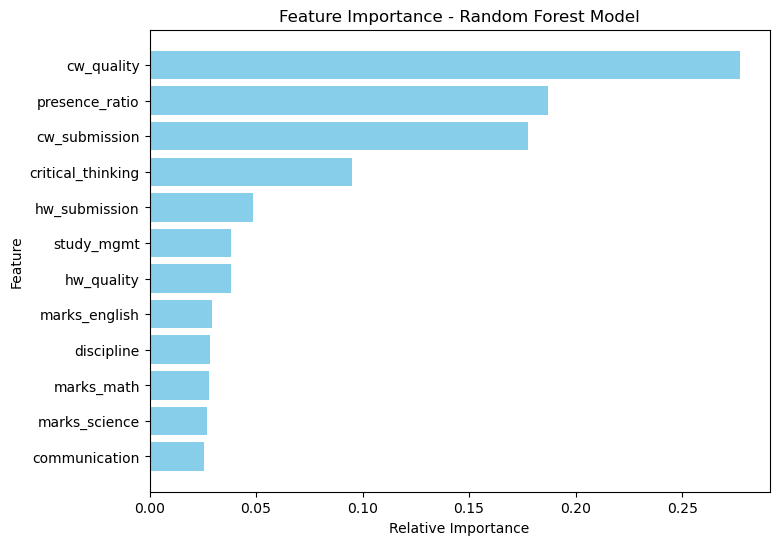

In [10]:
# =========================================================
# 8️⃣  Feature Importance Analysis
# =========================================================

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importance['Feature'], importance['Importance'], color='skyblue')
plt.title("Feature Importance - Random Forest Model")
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.show()

In [11]:

new_student = pd.DataFrame([{
    'presence_ratio': 0.92,
    'hw_submission': 0.9,
    'hw_quality': 0.85,
    'cw_submission': 0.8,
    'cw_quality': 0.9,
    'marks_math': 85,
    'marks_english': 78,
    'marks_science': 88,
    'communication': 0.85,
    'critical_thinking': 0.8,
    'discipline': 0.9,
    'study_mgmt': 0.85
}])

predicted_rating = model.predict(new_student)[0]
print(f"🎯 Predicted FIFA-style Rating for New Student: {predicted_rating:.2f}/100")

🎯 Predicted FIFA-style Rating for New Student: 64.97/100


J:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127918 (\N{VIDEO GAME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


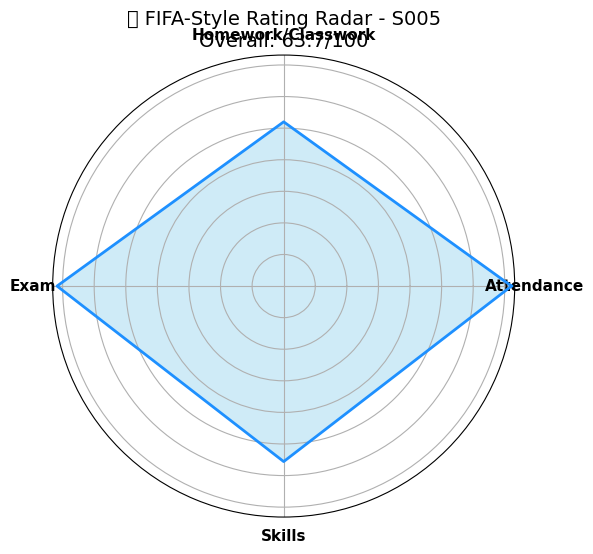

📋 Detailed Subcategory Ratings for S005

🔹 Attendance
   - Regular Absence          :  40.6
   - Holiday Absence          :  80.2
   - Sick Absence             :  75.2
   - Presence Ratio           :  72.8
   - Late Ratio               :  91.8

🔹 Homework/Classwork
   - HW Submission            :  46.1
   - HW Quality               :  61.7
   - CW Submission            :  23.9
   - CW Quality               :  76.3

🔹 Exam
   - Marks                    :  75.8
   - Answer Sensibility       :  96.8
   - Completion Rate          :  23.8
   - Unrelated Answers        :  90.6

🔹 Skills
   - Communication            :  97.8
   - Critical Thinking        :  44.8
   - Discipline               :  45.0
   - Study Management         :  34.8


In [12]:
# =========================================================
# 🔟  Visual FIFA-Style Student Rating Dashboard
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# Helper to compute subcategory ratings again (for detail visualization)
def get_subcategory_ratings(row):
    # Attendance sub-sectors
    r_att_regular = normalize(10 - row['absence_regular'], 0, 10)
    r_att_holiday = normalize(5 - (row['absence_before_holiday'] + row['absence_after_holiday']), 0, 5)
    r_att_sick = normalize(4 - row['absence_sick'], 0, 4)
    r_presence_ratio = normalize(row['presence_ratio'], 0.7, 1.0)
    r_late = normalize(1 - row['late_ratio'], 0, 1)

    # Homework/Classwork sub-sectors
    r_hw_sub = normalize(row['hw_submission'], 0.5, 1.0)
    r_hw_qual = normalize(row['hw_quality'], 0.5, 1.0)
    r_cw_sub = normalize(row['cw_submission'], 0.5, 1.0)
    r_cw_qual = normalize(row['cw_quality'], 0.5, 1.0)

    # Exam sub-sectors
    avg_marks = np.mean([row['marks_math'], row['marks_english'], row['marks_science']])
    r_marks = normalize(avg_marks, 40, 100)
    r_sensibility = normalize(row['answer_sensibility'], 0.5, 1.0)
    r_completion = normalize(row['completion_rate'], 0.6, 1.0)
    r_unrelated = normalize(1 - row['unrelated_answer'], 0, 1)

    # Skills sub-sectors
    r_comm = normalize(row['communication'], 0.5, 1.0)
    r_ct = normalize(row['critical_thinking'], 0.5, 1.0)
    r_discipline = normalize(row['discipline'], 0.5, 1.0)
    r_study = normalize(row['study_mgmt'], 0.5, 1.0)

    return {
        'Attendance': {
            'Regular Absence': r_att_regular,
            'Holiday Absence': r_att_holiday,
            'Sick Absence': r_att_sick,
            'Presence Ratio': r_presence_ratio,
            'Late Ratio': r_late
        },
        'Homework/Classwork': {
            'HW Submission': r_hw_sub,
            'HW Quality': r_hw_qual,
            'CW Submission': r_cw_sub,
            'CW Quality': r_cw_qual
        },
        'Exam': {
            'Marks': r_marks,
            'Answer Sensibility': r_sensibility,
            'Completion Rate': r_completion,
            'Unrelated Answers': r_unrelated
        },
        'Skills': {
            'Communication': r_comm,
            'Critical Thinking': r_ct,
            'Discipline': r_discipline,
            'Study Management': r_study
        }
    }

# Radar chart function
def plot_student_radar(student_id):
    s = students.loc[students['student_id'] == student_id].iloc[0]
    subcats = get_subcategory_ratings(s)

    # Extract main category averages
    main_cats = list(subcats.keys())
    main_scores = [np.mean(list(v.values())) for v in subcats.values()]

    # Radar chart setup
    angles = np.linspace(0, 2 * np.pi, len(main_cats), endpoint=False).tolist()
    main_scores += main_scores[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, main_scores, color='dodgerblue', linewidth=2)
    ax.fill(angles, main_scores, color='skyblue', alpha=0.4)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(main_cats, fontsize=11, fontweight='bold')
    ax.set_title(f"🎮 FIFA-Style Rating Radar - {student_id}\nOverall: {s['fifa_rating']:.1f}/100", fontsize=14)
    plt.show()

    # Print detailed sub-category table
    print("="*60)
    print(f"📋 Detailed Subcategory Ratings for {student_id}")
    print("="*60)
    for main, details in subcats.items():
        print(f"\n🔹 {main}")
        for sub, val in details.items():
            print(f"   - {sub:<25}: {val:>5.1f}")
    print("="*60)

# Example: visualize one student
plot_student_radar("S005")

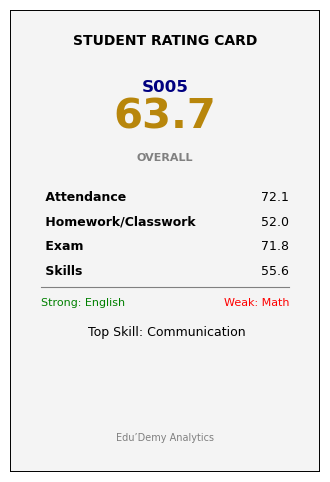

In [15]:
# =========================================================
# 1️⃣1️⃣  FIFA-Style Student Card Panel
# =========================================================

import matplotlib.patches as patches

def draw_fifa_card(student_id):
    s = students.loc[students['student_id'] == student_id].iloc[0]

    # Create figure
    fig, ax = plt.subplots(figsize=(4,6))
    ax.axis('off')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 150)

    # Background Card
    card = patches.FancyBboxPatch((0,0), 100,150,
                                  boxstyle="round,pad=0.02",
                                  edgecolor="black",
                                  facecolor="#f4f4f4",
                                  linewidth=1.5)
    ax.add_patch(card)

    # Header
    ax.text(50, 140, "STUDENT RATING CARD", ha='center', va='center',
            fontsize=10, fontweight='bold', color='black')

    # Student ID & Overall Rating
    ax.text(50, 125, f"{s['student_id']}", ha='center', va='center',
            fontsize=12, fontweight='bold', color='navy')
    ax.text(50, 115, f"{s['fifa_rating']:.1f}", ha='center', va='center',
            fontsize=30, fontweight='bold', color='darkgoldenrod')
    ax.text(50, 102, "OVERALL", ha='center', va='center',
            fontsize=8, fontweight='bold', color='gray')

    # Subcategory Ratings
    y = 88
    ax.text(10, y, " Attendance", fontweight='bold', fontsize=9)
    ax.text(90, y, f"{s['attendance_rating']:.1f}", ha='right', fontsize=9)
    y -= 8
    ax.text(10, y, " Homework/Classwork", fontweight='bold', fontsize=9)
    ax.text(90, y, f"{s['homework_classwork_rating']:.1f}", ha='right', fontsize=9)
    y -= 8
    ax.text(10, y, " Exam", fontweight='bold', fontsize=9)
    ax.text(90, y, f"{s['exam_rating']:.1f}", ha='right', fontsize=9)
    y -= 8
    ax.text(10, y, " Skills", fontweight='bold', fontsize=9)
    ax.text(90, y, f"{s['skill_rating']:.1f}", ha='right', fontsize=9)

    # Divider line
    ax.plot([10, 90], [y-4, y-4], color='gray', linewidth=0.8)
    y -= 10

    # Subject Strengths
    subject_scores = {
        'Math': s['marks_math'],
        'English': s['marks_english'],
        'Science': s['marks_science']
    }
    strong_subject = max(subject_scores, key=subject_scores.get)
    weak_subject = min(subject_scores, key=subject_scores.get)
    ax.text(10, y, f"Strong: {strong_subject}", fontsize=8, color='green')
    ax.text(90, y, f"Weak: {weak_subject}", fontsize=8, color='red', ha='right')
    y -= 10

    # Skill highlights
    top_skills = {
        'Communication': s['communication'],
        'Critical Thinking': s['critical_thinking'],
        'Discipline': s['discipline'],
        'Study Mgmt': s['study_mgmt']
    }
    top_skill = max(top_skills, key=top_skills.get)
    ax.text(50, y, f" Top Skill: {top_skill}", fontsize=9, color='black', ha='center')

    ax.text(50, 10, "Edu’Demy Analytics", ha='center', fontsize=7, color='gray')
    plt.show()

# Example Card
draw_fifa_card("S005")

In [16]:
# =========================================================
# 1️⃣2️⃣  Automatic Improvement Recommendations
# =========================================================

def get_focus_recommendations(student_id):
    s = students.loc[students['student_id'] == student_id].iloc[0]

    categories = {
        'Attendance': s['attendance_rating'],
        'Homework/Classwork': s['homework_classwork_rating'],
        'Exam': s['exam_rating'],
        'Skills': s['skill_rating']
    }

    # Identify weakest category
    weakest_cat = min(categories, key=categories.get)
    weakest_score = categories[weakest_cat]

    print("="*60)
    print(f"🎓 Student: {s['student_id']}")
    print(f"🏆 Overall Rating: {s['fifa_rating']:.1f}/100")
    print(f"⚠️ Weakest Area: {weakest_cat} ({weakest_score:.1f})")
    print("="*60)

    if weakest_cat == "Attendance":
        print("📅 Recommendation:")
        print("- Maintain a consistent daily routine.")
        print("- Address frequent absences before/after holidays.")
        print("- Communicate early if a class conflict arises.")
        print("- Practice time management to reduce late presence.")
    elif weakest_cat == "Homework/Classwork":
        print("📘 Recommendation:")
        print("- Improve homework quality through revision and teacher feedback.")
        print("- Submit classwork regularly before deadlines.")
        print("- Increase completion rate and double-check accuracy.")
    elif weakest_cat == "Exam":
        print("📝 Recommendation:")
        print("- Work on answer structuring and handwriting.")
        print("- Complete full paper during exams for better score ratio.")
        print("- Analyze question understanding; avoid unrelated answers.")
        print("- Practice mock exams to boost exam endurance.")
    elif weakest_cat == "Skills":
        print("🧠 Recommendation:")
        print("- Engage in presentations or group discussions to improve communication.")
        print("- Practice logical reasoning or puzzle-solving for critical thinking.")
        print("- Maintain discipline with study hours and focus consistency.")
        print("- Use digital tools to improve study-hour management.")
    print("="*60)

# Example recommendation
get_focus_recommendations("S005")

🎓 Student: S005
🏆 Overall Rating: 63.7/100
⚠️ Weakest Area: Homework/Classwork (52.0)
📘 Recommendation:
- Improve homework quality through revision and teacher feedback.
- Submit classwork regularly before deadlines.
- Increase completion rate and double-check accuracy.
